# ForecastLab

---

## Bike Sharing Demand Forecasting

---

| Informasi | Detail |
|-----------|--------|
| **Project ID** | FL-001 |
| **Eksperimen** | EXP-014 |
| **Nama Eksperimen** | Dashboard & Inference |
| **Dataset** | featured_data.csv |
| **Tujuan Notebook** | Dashboard interaktif untuk visualisasi hasil forecasting |
| **Author** | GAKUSEI Najib |

---

## 1. Tujuan

Menyediakan dashboard interaktif berbasis notebook untuk menampilkan hasil forecasting.

## Hipotesis
Dashboard mempermudah interpretasi hasil model dan pengambilan keputusan.

---
## 2. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
print('Library berhasil diimport.')

Library berhasil diimport.


---
## 3. Load Dataset & Model

In [2]:
INPUT_PATH = '../data/featured_data.csv'
df = pd.read_csv(INPUT_PATH)
df['dteday'] = pd.to_datetime(df['dteday'])
df = df.sort_values(by=['dteday', 'hr']).reset_index(drop=True)

exclude_cols = ['dteday', 'cnt', 'temp_actual', 'atemp_actual']
feature_cols = [c for c in df.columns if c not in exclude_cols]

train = df[df['yr'] == 0].copy()
test  = df[df['yr'] == 1].copy()

X_train = train[feature_cols].copy()
y_train = train['cnt'].copy()
X_test  = test[feature_cols].copy()
y_test  = test['cnt'].copy()

train_valid = X_train.dropna().index
X_train = X_train.loc[train_valid]
y_train = y_train.loc[train_valid]
test_valid = X_test.dropna().index
X_test = X_test.loc[test_valid]
y_test = y_test.loc[test_valid]

print(f'Data loaded: train={len(train_valid)}, test={len(test_valid)}')

Data loaded: train=8477, test=8734


In [3]:
MODEL_PATH = '../models/best_model.pkl'
METADATA_PATH = '../models/best_model.json'

if os.path.exists(MODEL_PATH):
    import joblib, json
    model = joblib.load(MODEL_PATH)
    with open(METADATA_PATH) as f:
        metadata = json.load(f)
    print(f'Model loaded: {metadata["model_name"]}')
    using_cached = True
else:
    from sklearn.ensemble import RandomForestRegressor
    model = RandomForestRegressor(n_estimators=200, max_depth=12, n_jobs=-1, random_state=42)
    model.fit(X_train, y_train)
    print('Model trained: Random Forest (fallback)')
    using_cached = False

y_pred = model.predict(X_test)

Model loaded: XGBoost Tuned


---
## 4. KPI Dashboard

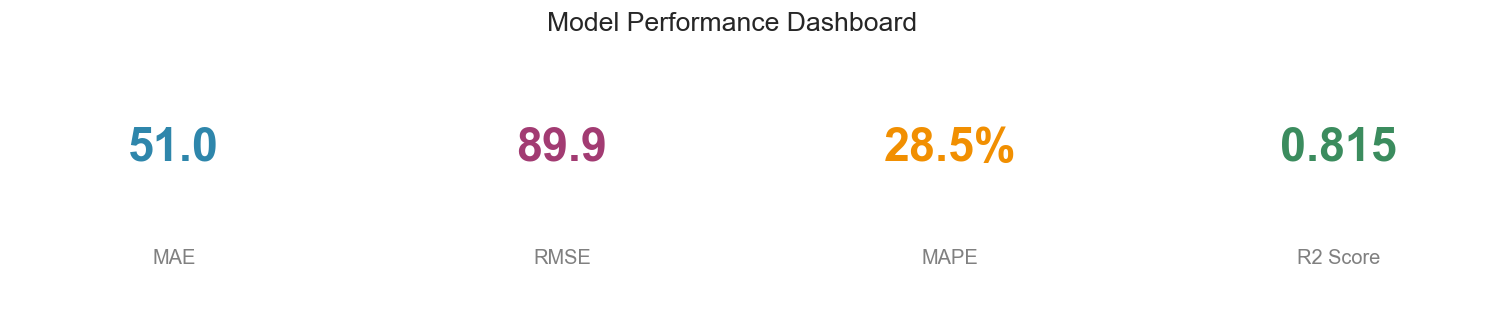

In [4]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-10))) * 100

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
metrics = [
    ('MAE', f'{mae:.1f}', '#2e86ab'),
    ('RMSE', f'{rmse:.1f}', '#a23b72'),
    ('MAPE', f'{mape:.1f}%', '#f18f01'),
    ('R2 Score', f'{r2:.3f}', '#3b8c5e'),
]
for ax, (title, value, color) in zip(axes, metrics):
    ax.text(0.5, 0.6, value, fontsize=28, fontweight='bold', ha='center', va='center', color=color)
    ax.text(0.5, 0.2, title, fontsize=12, ha='center', va='center', color='gray')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
plt.suptitle('Model Performance Dashboard', fontsize=16, y=0.95)
plt.savefig('../data/dash_01_kpi.png', bbox_inches='tight', dpi=120)
plt.show()

---
## 5. Prediksi vs Aktual (14 Hari)

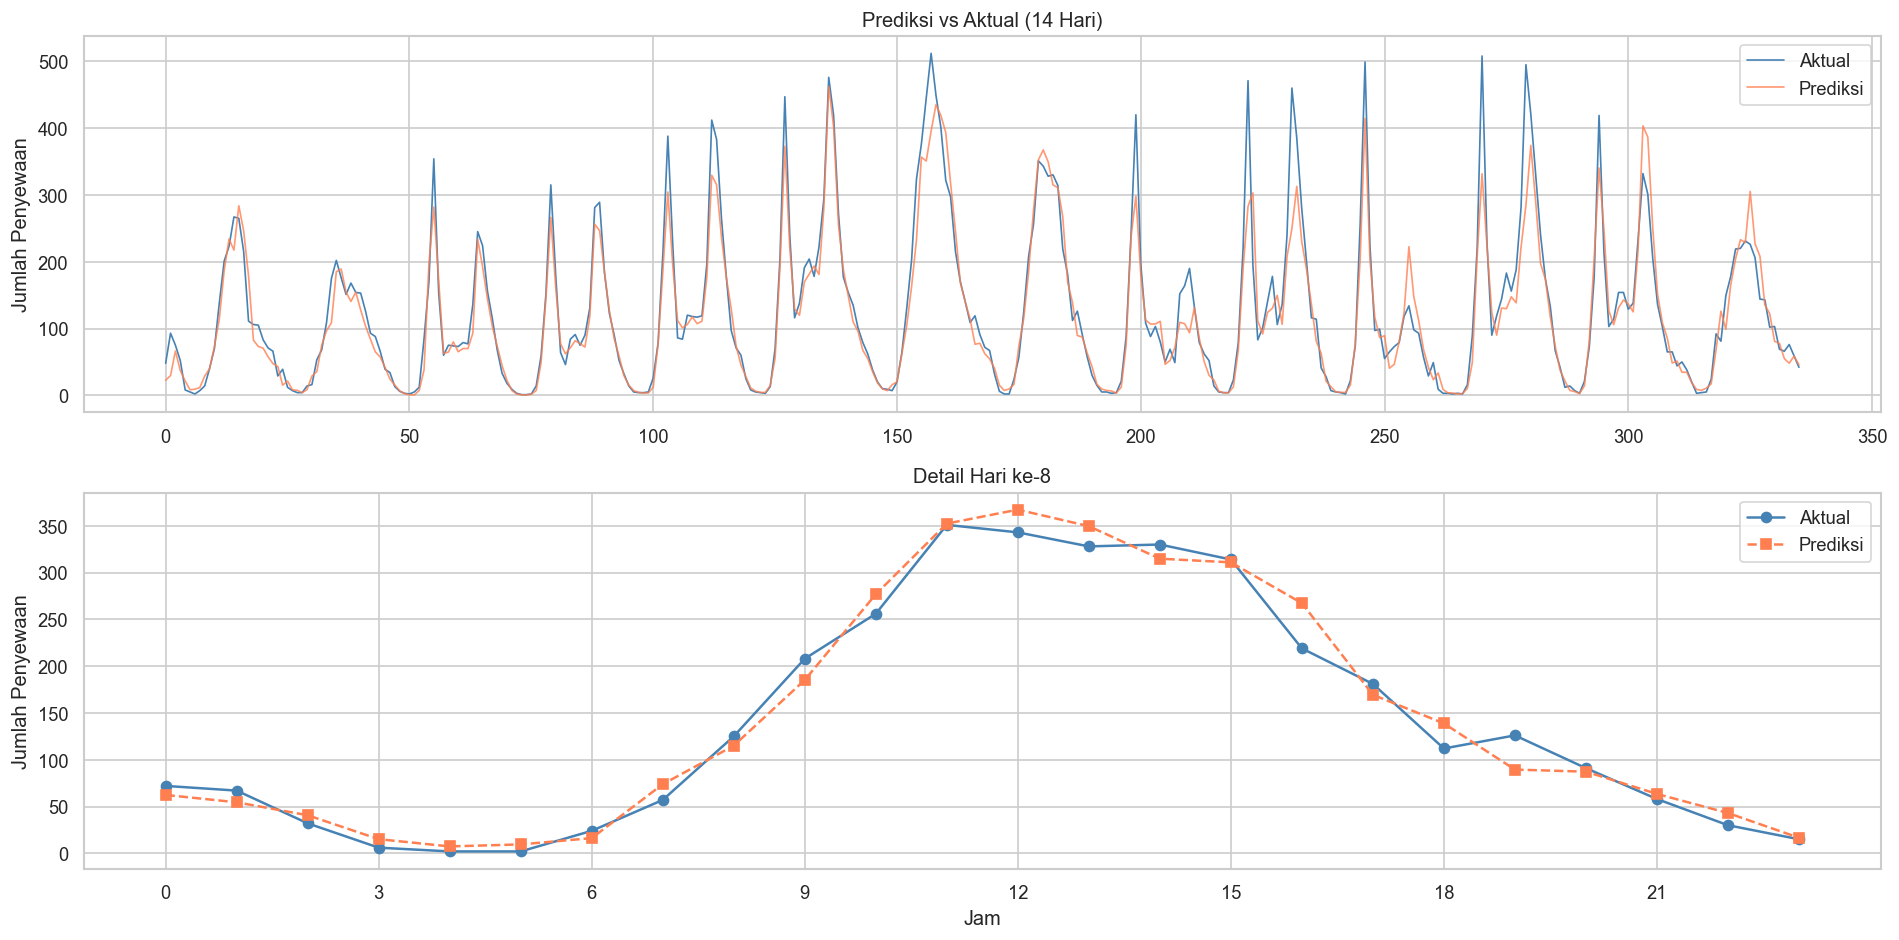

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

n_week = 336
x_vals = range(n_week)

axes[0].plot(x_vals, y_test.values[:n_week], label='Aktual', color='steelblue', linewidth=1)
axes[0].plot(x_vals, y_pred[:n_week], label='Prediksi', color='coral', alpha=0.8, linewidth=1)
axes[0].set_title('Prediksi vs Aktual (14 Hari)')
axes[0].legend()
axes[0].set_ylabel('Jumlah Penyewaan')

n_day = 24
day_idx = 7
start = day_idx * 24
end = start + n_day
x_day = range(n_day)

axes[1].plot(x_day, y_test.values[start:end], 'o-', label='Aktual', color='steelblue')
axes[1].plot(x_day, y_pred[start:end], 's--', label='Prediksi', color='coral')
axes[1].set_title(f'Detail Hari ke-{day_idx+1}')
axes[1].legend()
axes[1].set_xlabel('Jam')
axes[1].set_ylabel('Jumlah Penyewaan')
axes[1].set_xticks(range(0, 24, 3))

plt.tight_layout()
plt.savefig('../data/dash_02_prediction.png', bbox_inches='tight', dpi=120)
plt.show()

---
## 6. Rata-rata Prediksi per Jam

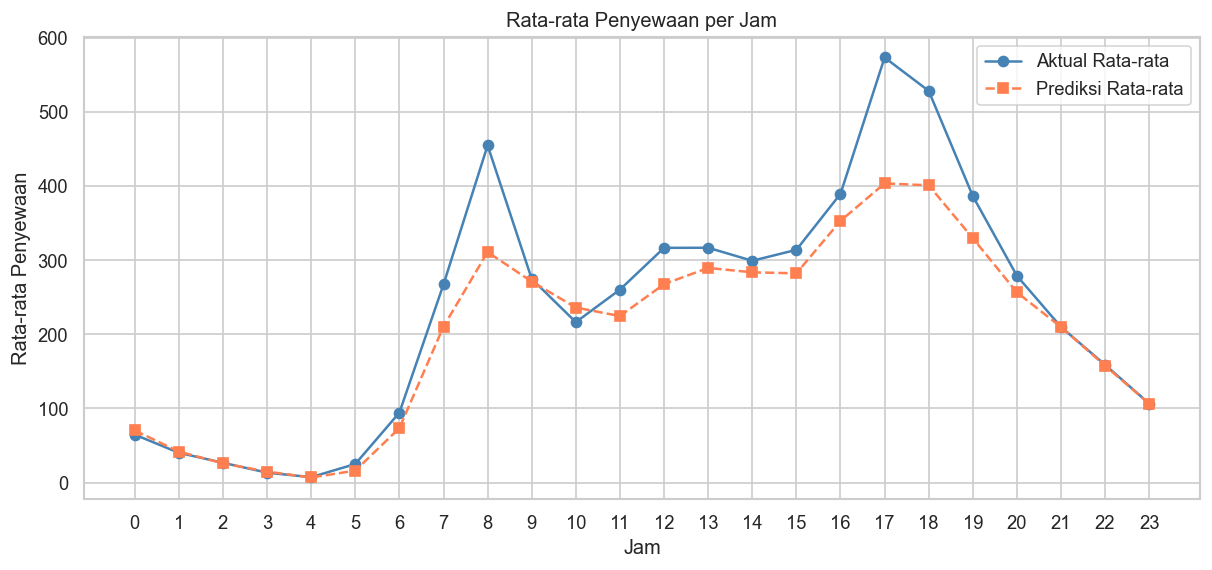

In [6]:
test_hr = test.loc[test_valid, 'hr'].values
hourly_actual = pd.DataFrame({'hr': test_hr, 'cnt': y_test}).groupby('hr')['cnt'].mean()
hourly_pred   = pd.DataFrame({'hr': test_hr, 'cnt': y_pred}).groupby('hr')['cnt'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly_actual.index, hourly_actual.values, 'o-', label='Aktual Rata-rata', color='steelblue')
ax.plot(hourly_pred.index, hourly_pred.values, 's--', label='Prediksi Rata-rata', color='coral')
ax.set_title('Rata-rata Penyewaan per Jam')
ax.set_xlabel('Jam')
ax.set_ylabel('Rata-rata Penyewaan')
ax.set_xticks(range(0, 24))
ax.legend()
plt.savefig('../data/dash_03_hourly_pattern.png', bbox_inches='tight', dpi=120)
plt.show()

---
## 7. Feature Importance

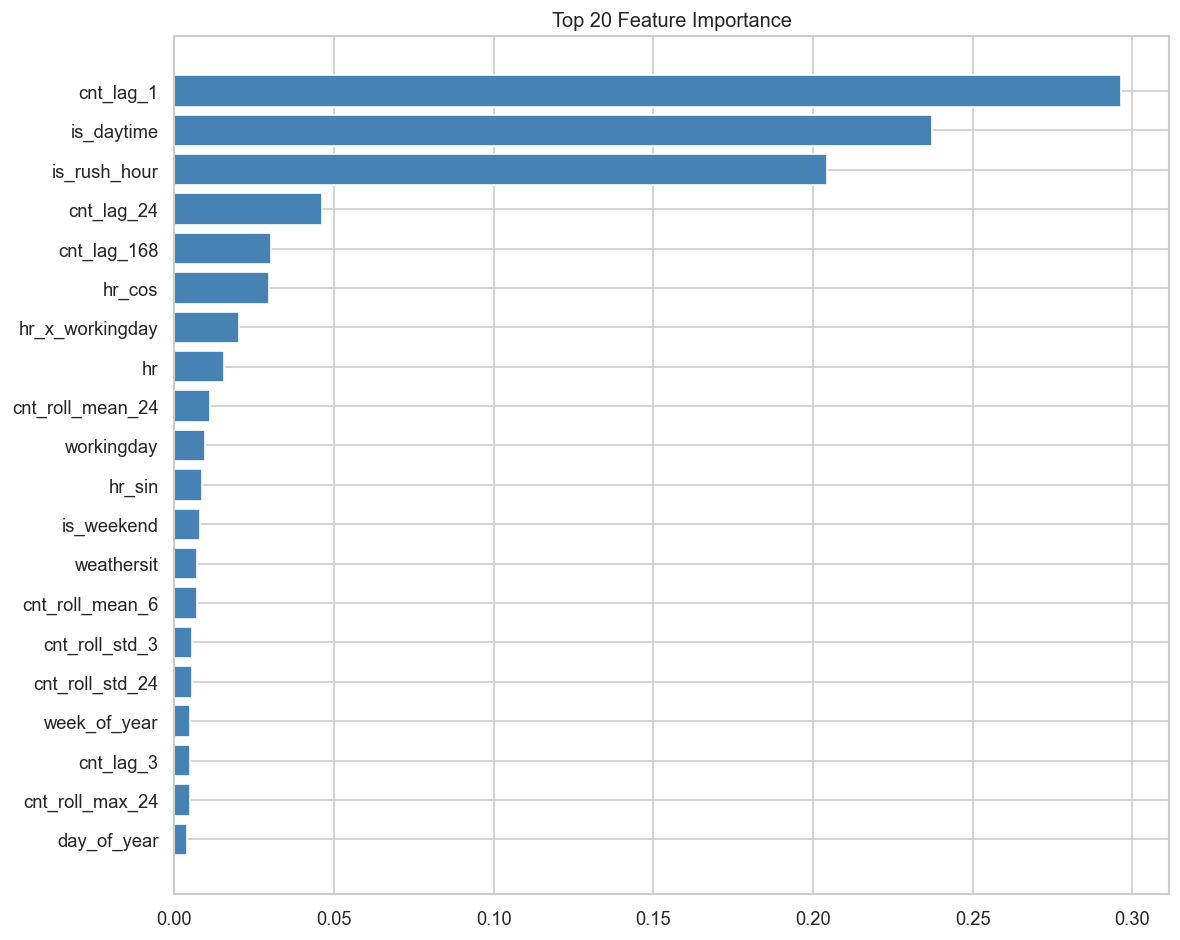

In [7]:
if hasattr(model, 'feature_importances_'):
    importances = pd.DataFrame({'Feature': feature_cols, 'Importance': model.feature_importances_})
    importances = importances.sort_values('Importance', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(importances['Feature'][-20:], importances['Importance'][-20:], color='steelblue', edgecolor='white')
    ax.set_title('Top 20 Feature Importance')
    plt.tight_layout()
    plt.savefig('../data/dash_04_importance.png', bbox_inches='tight', dpi=120)
    plt.show()
else:
    print('Model ini tidak memiliki feature_importances_.')

---
## 8. Historical vs Predicted Trend

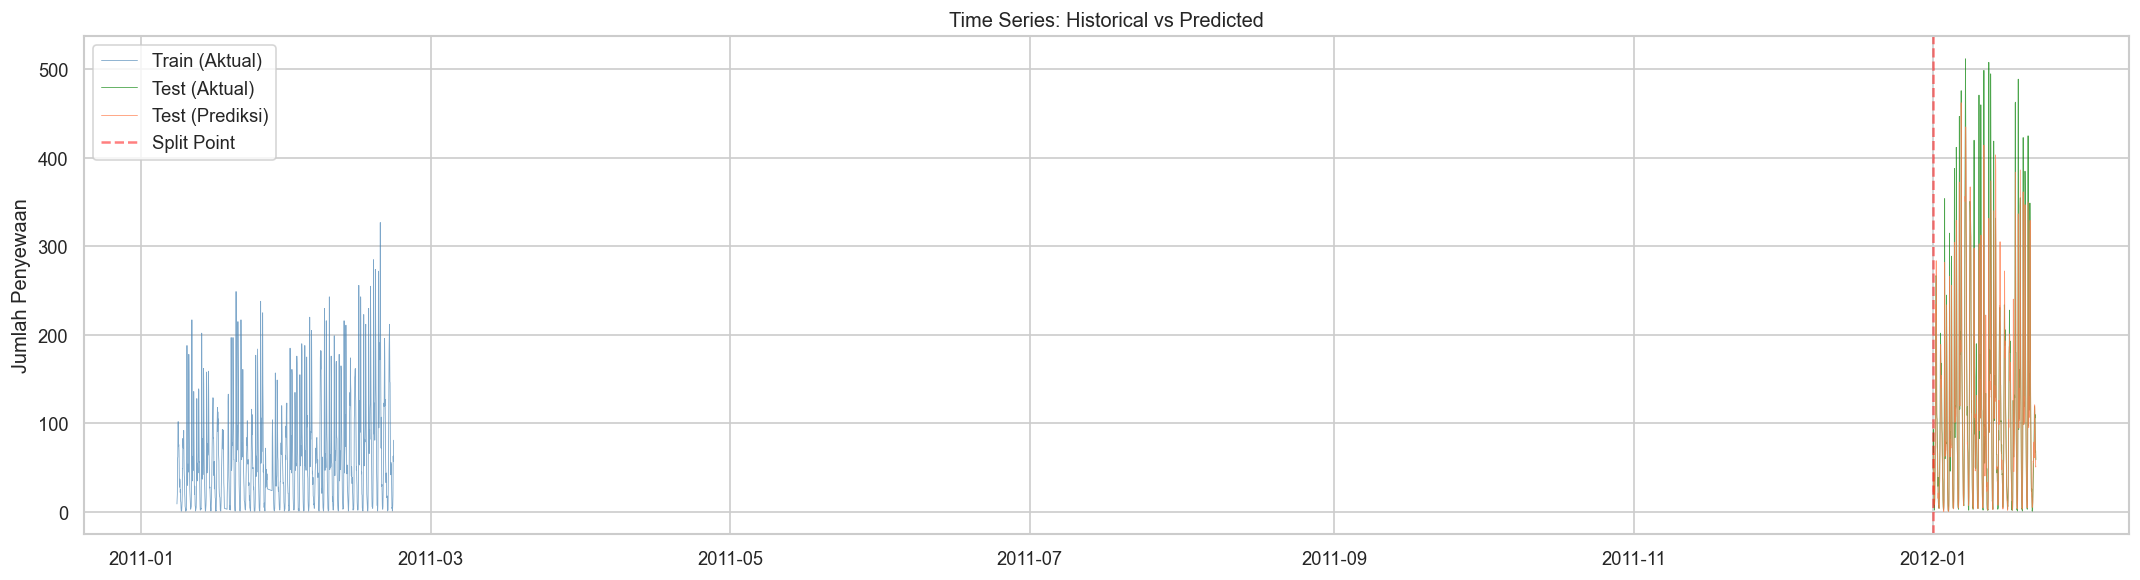

In [8]:
train_dates = train.loc[train_valid, 'dteday'].dt.strftime('%Y-%m-%d')
train_hr = train.loc[train_valid, 'hr']
train_dt = pd.to_datetime(train_dates + ' ' + train_hr.astype(str) + ':00:00')

test_dates = test.loc[test_valid, 'dteday'].dt.strftime('%Y-%m-%d')
test_hr = test.loc[test_valid, 'hr']
test_dt = pd.to_datetime(test_dates + ' ' + test_hr.astype(str) + ':00:00')

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(train_dt.values[:1000], y_train.values[:1000], label='Train (Aktual)', color='steelblue', alpha=0.7, linewidth=0.5)
ax.plot(test_dt.values[:500], y_test.values[:500], label='Test (Aktual)', color='green', alpha=0.7, linewidth=0.5)
ax.plot(test_dt.values[:500], y_pred[:500], label='Test (Prediksi)', color='coral', alpha=0.8, linewidth=0.5)
ax.axvline(x=train_dt.values[-1], color='red', linestyle='--', alpha=0.5, label='Split Point')
ax.set_title('Time Series: Historical vs Predicted')
ax.set_ylabel('Jumlah Penyewaan')
ax.legend()
plt.tight_layout()
plt.savefig('../data/dash_05_timeseries.png', bbox_inches='tight', dpi=120)
plt.show()

---
## 9. Kesimpulan

Dashboard menampilkan:
- **KPI Cards**: MAE, RMSE, MAPE, R2
- **Prediction Plot**: Aktual vs Prediksi (14 hari + detail harian)
- **Hourly Pattern**: Rata-rata penyewaan per jam
- **Feature Importance**: Fitur paling berpengaruh
- **Time Series View**: Historis dan prediksi

Dashboard siap digunakan untuk monitoring dan presentasi.

**Next: EXP-015 Final Documentation**